In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")

<Axes: xlabel='total_bill', ylabel='tip'>

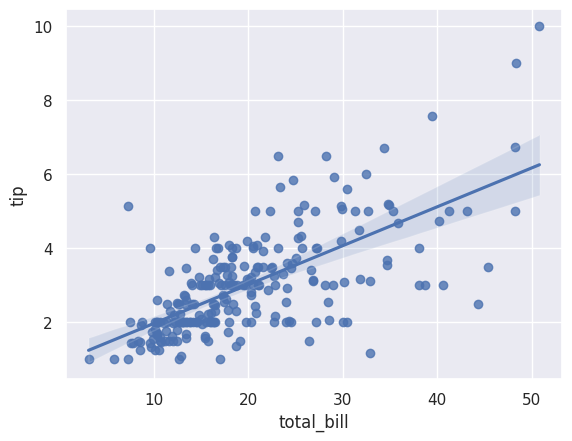

In [2]:
tips = sns.load_dataset("tips")
sns.regplot(x="total_bill", y="tip", data=tips)

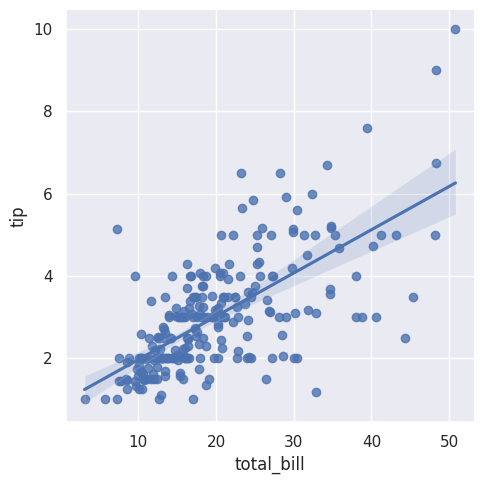

In [3]:
sns.lmplot(x="total_bill", y="tip", data=tips)

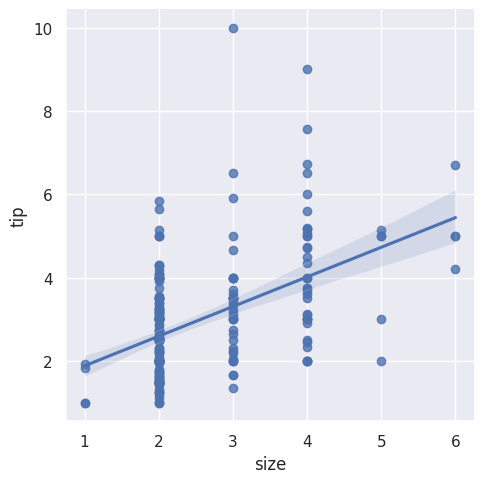

In [4]:
sns.lmplot(x="size", y="tip", data=tips);

- One option is to add some random noise (“jitter”) to the discrete values to make the distribution of those values more clear. Note that jitter is applied only to the scatterplot data and does not influence the regression line fit itself:

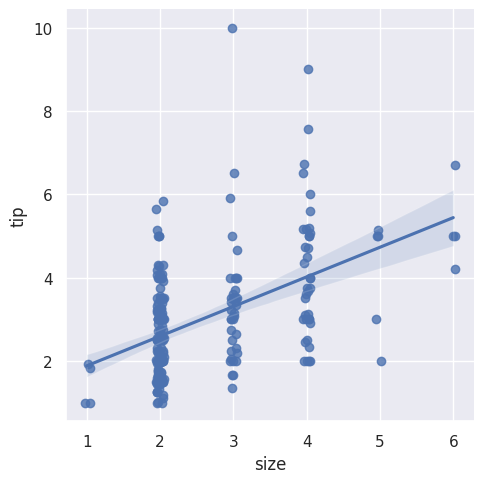

In [5]:
sns.lmplot(x="size", y="tip", data=tips, x_jitter=.05)

- A second option is to collapse over the observations in each discrete bin to plot an estimate of central tendency along with a confidence interval:

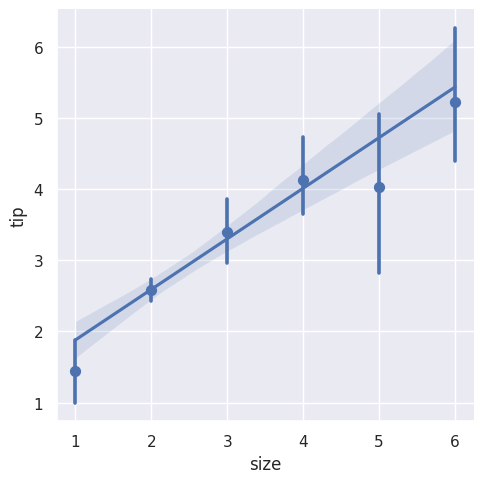

In [6]:
sns.lmplot(x="size", y="tip", data=tips, x_estimator=np.mean)

### Fitting different kinds of models

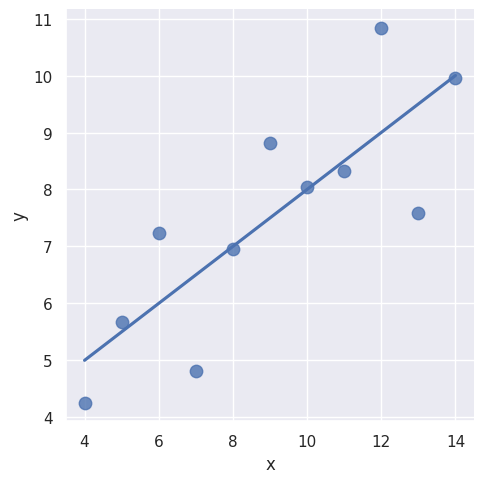

In [7]:
anscombe = sns.load_dataset("anscombe")
sns.lmplot(x="x", y="y", data=anscombe.query("dataset == 'I'"),
           ci=None, scatter_kws={"s": 80})

- The linear relationship in the second dataset is the same, but the plot clearly shows that this is not a good model:

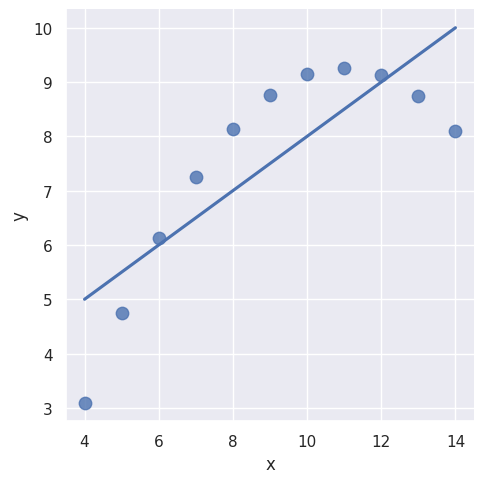

In [8]:
anscombe = sns.load_dataset("anscombe")
sns.lmplot(x="x", y="y", data=anscombe.query("dataset == 'II'"),
           ci=None, scatter_kws={"s": 80})

- In the presence of these kind of higher-order relationships, lmplot() and regplot() can fit a polynomial regression model to explore simple kinds of nonlinear trends in the dataset:

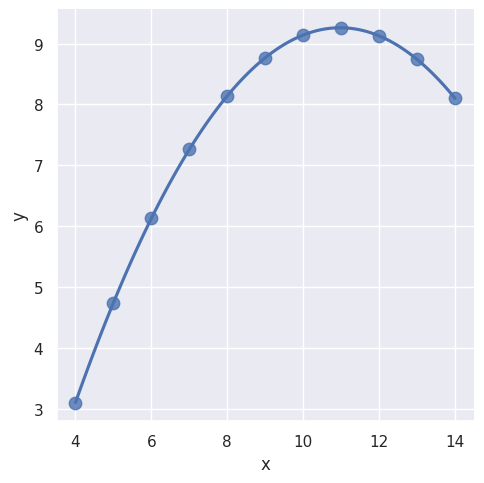

In [9]:
sns.lmplot(x="x", y="y", data=anscombe.query("dataset == 'II'"),
           order=2, ci=None, scatter_kws={"s": 80});

- A different problem is posed by “outlier” observations that deviate for some reason other than the main relationship under study:



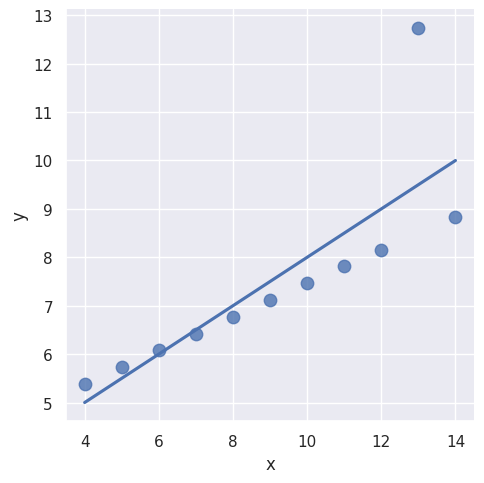

In [10]:
sns.lmplot(x="x", y="y", data=anscombe.query("dataset == 'III'"),
           ci=None, scatter_kws={"s": 80})

- In the presence of outliers, it can be useful to fit a robust regression, which uses a different loss function to downweight relatively large residuals:

In [12]:
!pip install statsmodel

/bin/bash: line 1: /home/jeremy/Documents/Work/Learning/visualization/venv/bin/pip: cannot execute: required file not found


In [ ]:
sns.lmplot(x="x", y="y", data=anscombe.query("dataset == 'III'"),
           robust=True, ci=None, scatter_kws={"s": 80});

- When the y variable is binary, simple linear regression also “works” but provides implausible predictions:

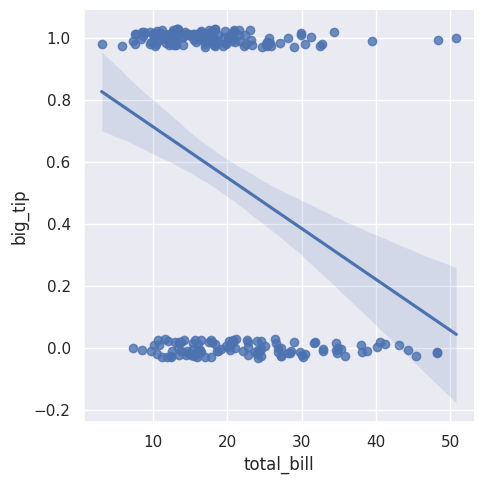

In [14]:
tips["big_tip"] = (tips.tip / tips.total_bill) > .15
sns.lmplot(x="total_bill", y="big_tip", data=tips,
           y_jitter=.03)

- The solution in this case is to fit a logistic regression, such that the regression line shows the estimated probability of y = 1 for a given value of x:

In [ ]:
sns.lmplot(x="total_bill", y="big_tip", data=tips,
           logistic=True, y_jitter=.03)

In [ ]:
sns.lmplot(x="total_bill", y="tip", data=tips,
           lowess=True, line_kws={"color": "C1"});

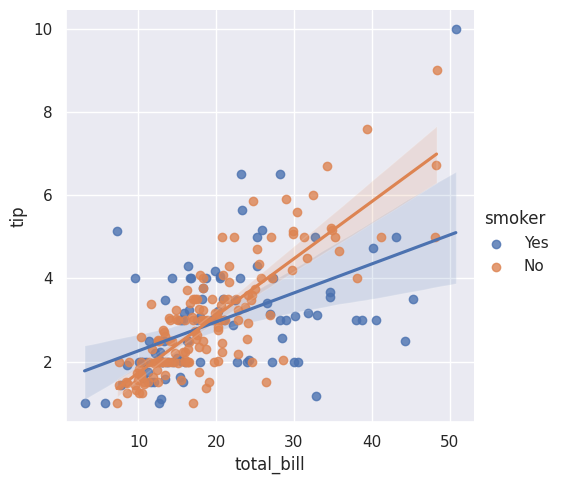

In [19]:
sns.lmplot(x="total_bill", y="tip", hue="smoker", data=tips);

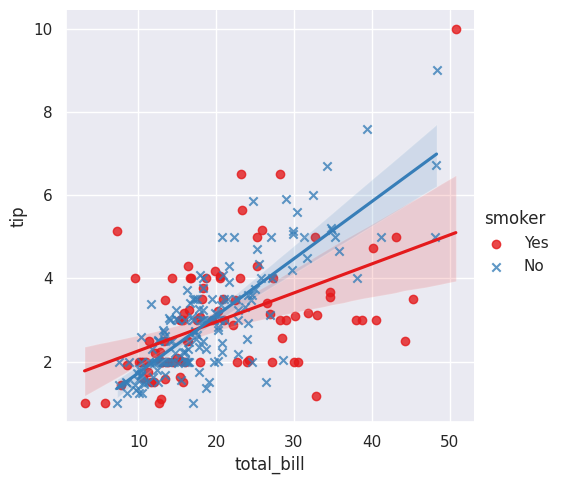

In [20]:
sns.lmplot(x="total_bill", y="tip", hue="smoker", data=tips,
           markers=["o", "x"], palette="Set1")

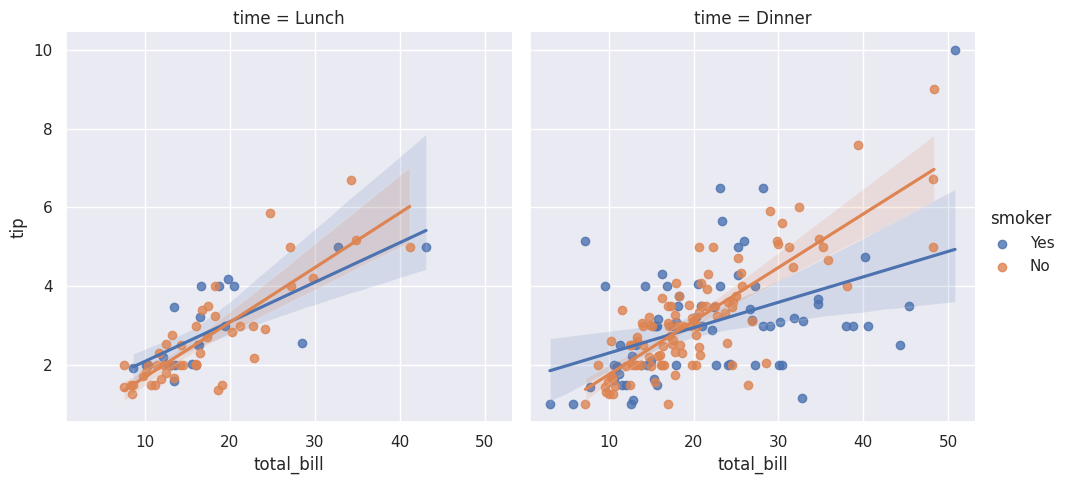

In [21]:
sns.lmplot(x="total_bill", y="tip", hue="smoker", col="time", data=tips);

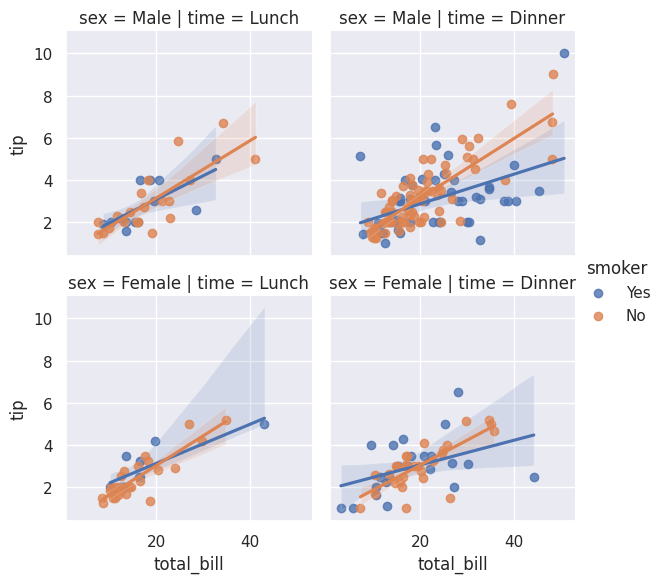

In [22]:
sns.lmplot(x="total_bill", y="tip", hue="smoker",
           col="time", row="sex", data=tips, height=3)

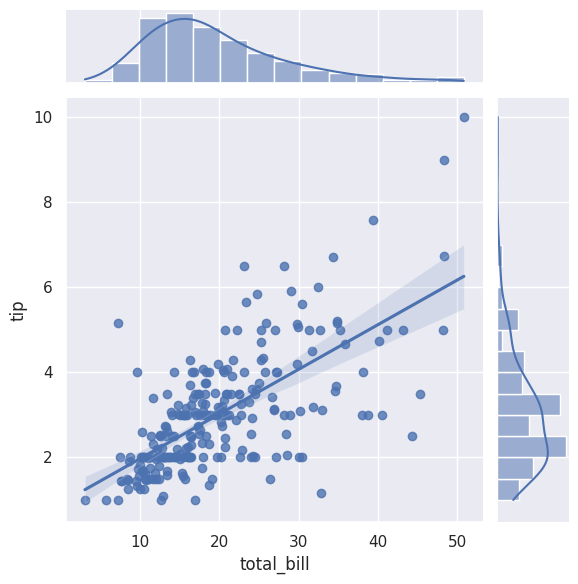

In [23]:
sns.jointplot(x="total_bill", y="tip", data=tips, kind="reg")

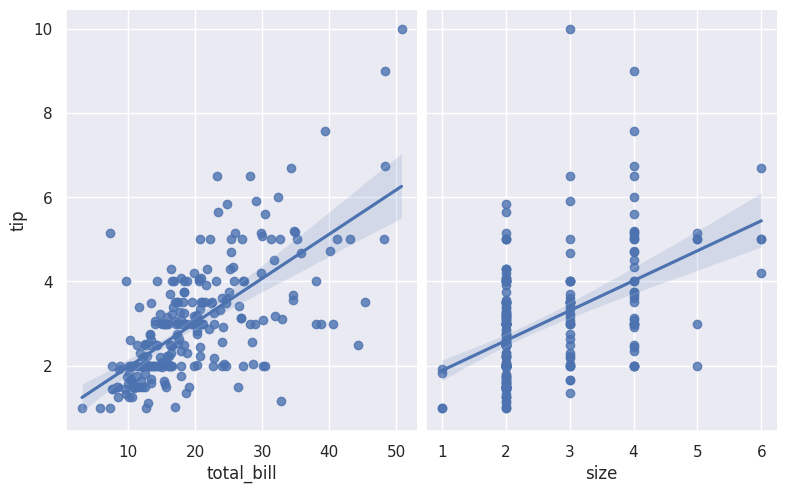

In [24]:
sns.pairplot(tips, x_vars=["total_bill", "size"], y_vars=["tip"],
             height=5, aspect=.8, kind="reg")

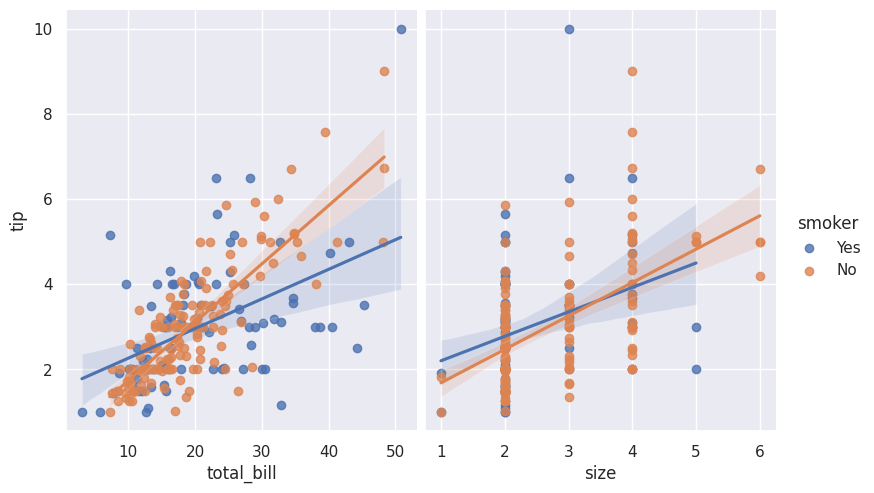

In [25]:
sns.pairplot(tips, x_vars=["total_bill", "size"], y_vars=["tip"],
             hue="smoker", height=5, aspect=.8, kind="reg");